In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Set plotting parameters for figures
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [3]:
# Import catrace functions and load dataset configuration
from catrace.exp_collection import read_df
from catrace.dataset import load_dataset_config
dsconfig = load_dataset_config('../dataset_configs/juvenile_dataset_t7.json')

In [4]:
from catrace.exp_collection import concatenate_df_from_db
all_dff = concatenate_df_from_db(dsconfig.processed_trace_dir, dsconfig.exp_list)


2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-02-05-DpOBEM-JH9_Dp None
2021-03-18-DpOBEM-JH10_Dp None
2021-03-19-DpOBEM-JH10_Dp None
2021-04-02-DpOBEM-JH11_Dp None
2021-04-03-DpOBEM-JH11_Dp None
2021-05-01-DpOBEM-JH13_Dp None
2021-05-22-DpOBEM-JH14_Dp None
2021-09-15-DpOBEM-JH20_Dp None
2021-09-17-DpOBEM-JH20_Dp None
2021-09-18-DpOBEM-JH20_Dp None
2021-07-30-DpOBEM-JH17_Dp None
2021-07-31-DpOBEM-JH17_Dp None
2021-09-02-DpOBEM-JH18_Dp None
2021-09-03-DpOBEM-JH18_Dp None
2021-09-04-DpOBEM-JH18_Dp None
2021-09-29-DpOBEM-JH21_Dp None
2021-10-01-DpOBEM-JH21_Dp None
2021-10-02-DpOBEM-JH21_Dp None
2021-10-14-DpOBEM-JH22_Dp None
2021-11-10-DpOBEM-JH23_Dp None
2021-11-11-DpOBEM-JH23_Dp None
2021-11-14-DpOBEM-JH23_Dp None
2021-11-24-DpOBEM-JH24_Dp None
2021-11-27-DpOBEM-JH24_Dp None
2021-11-26-DpOBEM-JH24_Dp None


In [5]:
# Select some neurons that are responsive to both odors
cut_time = 2.3 # The traces showed be shifted to the left by 2.3s, so that the odor onset is approximately 2s
cut_frame = int(cut_time * dsconfig.frame_rate)
begin_time = cut_time +0
begin_frame = int(begin_time * dsconfig.frame_rate)
total_time = 12 # Total time to plot, 10s
total_frame = int(total_time * dsconfig.frame_rate)
frame_range = (begin_frame, begin_frame + total_frame) # Frame range to select from the saved firing rate dataframe

# Select the frames
from catrace.process_time_trace import select_time_points
dff = select_time_points(all_dff, frame_range)






In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Function for clustering neurons based on timecourses
def cluster_neurons(dff, num_clusters, random_state=42):
    X = dff.values.T  # shape (n_neurons, n_frames)

    # 2) Z-score each neuron across frames
    # StandardScaler works column-wise, so do it manually row-wise
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X.T).T

    # 3) Run k-means
    kmeans = KMeans(n_clusters=num_clusters, random_state=random_state)
    labels = kmeans.fit_predict(Xz)
    return labels


C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_sorted.groupby(labels_sorted, axis=1).mean()


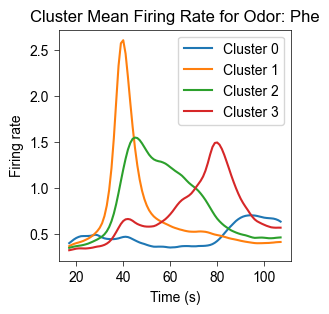

C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_sorted.groupby(labels_sorted, axis=1).mean()


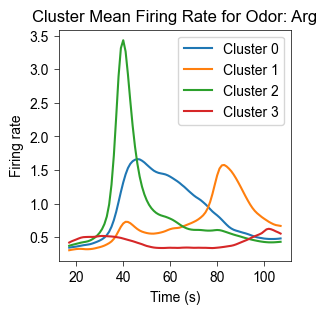

C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_sorted.groupby(labels_sorted, axis=1).mean()


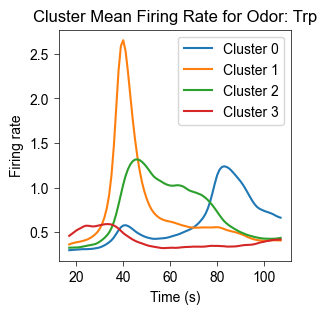

C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_sorted.groupby(labels_sorted, axis=1).mean()


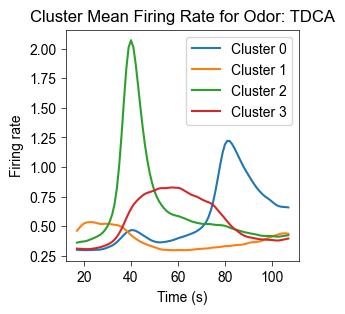

C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_sorted.groupby(labels_sorted, axis=1).mean()


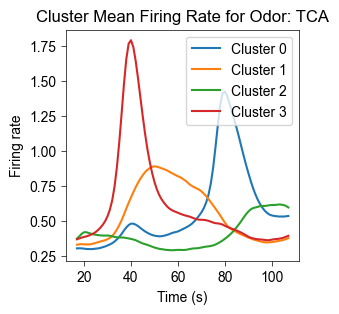

C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_sorted.groupby(labels_sorted, axis=1).mean()


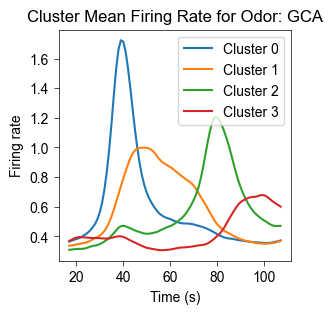

In [7]:
# Select odors
from catrace.process_time_trace import select_odors_df

def cluster_for_odor(dff, odor, random_state=42):
    selected_odors = [odor]
    dff_odor = select_odors_df(dff, selected_odors)
    # Average over all trials
    dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
    labels = cluster_neurons(dff_odor, num_clusters=4, random_state=random_state)
    return labels, dff_odor

def compute_cluster_mean(dff, labels):
    # Sort dff columns by cluster label
    sorted_idx = np.argsort(labels)
    dff_sorted = dff.iloc[:, sorted_idx]
    # Optional: sorted labels to match the reordered columns
    labels_sorted = labels[sorted_idx]
    # Compute mean firing rate for each cluster
    mean_firing_rate = dff_sorted.groupby(labels_sorted, axis=1).mean()
    return mean_firing_rate

def plot_cluster_mean(mean_firing_rate, color_cycle=None):
    # Plot mean firing rate for each cluster
    fig, ax = plt.subplots(figsize=(3, 3))
    if color_cycle is not None:
        ax.set_prop_cycle(color=color_cycle)
    for cluster in mean_firing_rate.columns:
        ax.plot(mean_firing_rate.index.get_level_values('time'), mean_firing_rate[cluster], label=f'Cluster {cluster}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Firing rate')
    ax.legend()
    return fig, ax


# Iterate over odors and plot cluster means
odors = dsconfig.odors_stimuli
label_dict = {}
for odor in odors:
    labels, dff_odor = cluster_for_odor(dff, odor)
    label_dict[odor] = labels
    mean_firing_rate = compute_cluster_mean(dff_odor, labels)
    fig, ax = plot_cluster_mean(mean_firing_rate)
    ax.set_title(f'Cluster Mean Firing Rate for Odor: {odor}')
    plt.show()

In [8]:
# Permute the cluster labels so that the timecourse types match across odors
order_dict = {
    "Phe": [3, 0, 1, 2],
    "Arg": [0, 2, 3, 1],
    "Trp": [3, 1, 2, 0],
    "TDCA": [2, 1, 3, 0],
    "TCA": [0, 1, 2, 3],
    "GCA": [0, 1, 2, 3]
}

matched_label_dict = {}
for odor in odors:
    cluster_order = order_dict[odor]
    # For Phe, map 1 to 0, 2 to 1, 3 to 2, 0 to 3
    cluster_labels = label_dict[odor]
    matched_cluster_labels = np.array([cluster_order.index(label) for label in cluster_labels])
    matched_label_dict[odor] = matched_cluster_labels

C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1919574664.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1487243753.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_firing_rate = dff_sorted.groupby(labels_sorted, axis=1).mean()
C:\Users\hubob\AppData\Local\Temp\ipykernel_7776\1919574664.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
C:\Users\hubob\AppData\Local\

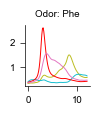

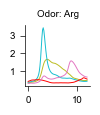

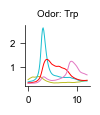

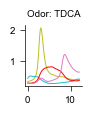

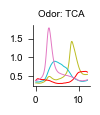

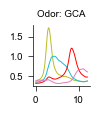

In [9]:
def extract_dff_odor(dff, odor):
    dff_odor = select_odors_df(dff, [odor])
    dff_odor = dff_odor.groupby(level=['odor', 'time']).mean()
    return dff_odor

import os
paper_fig_root_dir = '../../figures_for_paper'
dataset_name = 'juvenile'
paper_fig_dir = os.path.join(paper_fig_root_dir, dataset_name, 'offset_cluster_mean')
os.makedirs(paper_fig_dir, exist_ok=True)
from catrace.for_paper import save_figure_for_paper

import seaborn as sns
def plot_cluster_mean_for_paper(mean_firing_rate, color_cycle=None):
    # Plot mean firing rate for each cluster
    fig, ax = plt.subplots(figsize=(1.1, 1.1))
    if color_cycle is not None:
        ax.set_prop_cycle(color=color_cycle)
    time_vec = np.arange(mean_firing_rate.shape[0]) / dsconfig.frame_rate
    for cluster in mean_firing_rate.columns:
        ax.plot(time_vec, mean_firing_rate[cluster], label=f'Cluster {cluster}', linewidth=0.7)
    #ax.set_xlabel('Time (s)', fontsize=7)
    #ax.set_ylabel('Z-scored firing rate', fontsize=7)
    # Set tick label font size to 7
    ax.tick_params(axis='both', which='major', labelsize=7)
    # ax.legend(fontsize=7)
    sns.despine(ax=ax)
    plt.tight_layout()
    return fig, ax



#color_cycle = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
color_cycle = ["tab:olive", "tab:cyan", "red", "tab:pink"]
odors = dsconfig.odors_stimuli
#odors = ['Arg']
for odor in odors:
    dff_odor = extract_dff_odor(dff, odor)
    labels = matched_label_dict[odor]
    mean_firing_rate = compute_cluster_mean(dff_odor, labels)
    fig, ax = plot_cluster_mean_for_paper(mean_firing_rate, color_cycle= color_cycle)
    ax.set_title(f'Odor: {odor}', fontsize=7)
    save_figure_for_paper(fig, f'offset_cluster_mean_{odor}', paper_fig_dir)

In [10]:
# Save the matched labels for later use
import pandas as pd
import os
file_path = os.path.join(dsconfig.results_dir, 'offset_responsive_cluster')
os.makedirs(file_path, exist_ok=True)
# Convert matched_label_dict to a DataFrame
matched_label_df = pd.DataFrame(matched_label_dict)
# Save to CSV
#matched_label_df.to_csv(os.path.join(file_path, 'matched_cluster_labels.csv'), index=False)
# Set the index the same as the neuron index in dff
matched_label_df.index = dff.columns
matched_label_df
# Save as pickle
matched_label_df.to_pickle(os.path.join(file_path, 'matched_cluster_labels.pkl'))
